# Dependencies

In [1]:
import datetime
import yaml
import numpy as np
import pandas as pd
import pathlib
import tensorflow as tf
import keras
from tensorflow.keras.callbacks import TensorBoard, EarlyStopping
import matplotlib.pyplot as plt

from src.data.prepare_data import prepare_non_rnn_data, prepare_rnn_data, concatenate_multi_input_data
from src.train.models import build_dmq_v0, build_dmq, build_linear_model, build_nn, build_rnn
from src.train.losses import make_total_tilted_loss, tilted_loss, make_tilted_loss
from src.utils.evaluation import compute_oos_r1_score, compute_oos_r2_score

keras.config.set_floatx("float32")
keras.utils.set_random_seed(1)
# =====================================================================
# Configuration
# =====================================================================
# Load config for defaults
with open("config/config_file.yaml", "r") as f:
    config = yaml.safe_load(f)

BASE_PATH = pathlib.Path('.')
data_config = config['data']
INPUT_FILES = [
    'us_4q_fred_x.csv'
]
TARGET_FILE = data_config['target_file']
TARGETS_PATH = BASE_PATH/ 'data' / 'processed' / TARGET_FILE
INPUT_PATHS = [BASE_PATH / 'data' / 'processed' / file for file in INPUT_FILES]
START_DATE = data_config['start_date']
USE_LAGS = False

TARGETS  = ['Infl_yoy', 'IP_yoy', 'Unrate_yoy']
TARGET_DICT = {
    0: 'Infl_yoy',
    1: 'IP_yoy',
    2: 'Unrate_yoy'
}
AR_DICT = {
    target: BASE_PATH / 'data' / 'processed' / f'us_4q_{target}_ar_x.csv'
    for target in TARGETS
}

# Data configurations
TARGET_IDX = 0  # 0: Infl_yoy, 1: IP_yoy, 2: Unrate_yoy
INPUT_PATHS.append(
    AR_DICT[TARGET_DICT[TARGET_IDX]]
)

TIME_STEPS = 12  # Number of quarters for RNN
YEAR = 1997     # Train cutoff year
VAL_MONTHS = 60   # Number of validation years
TEST_MONTHS = 240

QUANTILES = [0.05, 0.25, 0.5, 0.75, 0.95]
EPOCHS = 500
BATCH_SIZE = 4
LEARNING_RATE = 0.001

target_name_dict = {
    0: 'Infl_yoy',
    1: 'IP_yoy',
    2: 'Unrate_yoy',
}

target_name = target_name_dict[TARGET_IDX]
print(f"Experimental framework for target: {target_name}")

Experimental framework for target: Infl_yoy


# Helper functions

In [2]:
def plot_predictions(
        y_pred, 
        y_true,
        multi_quantile=False
):
    
    plt.plot(y_true, label='Actual values')
    if multi_quantile:
        for i in range(y_pred.shape[1]):
            plt.plot(y_pred[:,i], label=f'Predicted Q{i+1} values')
    else:
        plt.plot(y_pred, label='Predicted')
    plt.legend()
    plt.show()


def evaluate_predictions(
        y_pred,
        y_true,
        mean_benchmark = None,
        q_benchmarks = None,
        quantiles = None,
        eval_quantiles = True
):
    
    if q_benchmarks is None and quantiles is None and eval_quantiles:
        raise ValueError(
            (
                "quantiles must be provided if quantiles benchmarks are not"
                "provided"
            )
        )

    if q_benchmarks is None and eval_quantiles:
        q_benchmarks = []
        for q in quantiles:
            q_y_true = np.quantile(y_true, q)
            q_benchmarks.append(
                np.full_like(y_true, fill_value=q_y_true).reshape(-1,1)
            )
        q_benchmarks = np.concatenate(q_benchmarks, axis=1)

    if mean_benchmark is None:
        mean_benchmark = np.full_like(
            y_true,
            fill_value=y_true.mean()
        )

    if eval_quantiles:
        r1_all = []
        for i,q in enumerate(QUANTILES):

            r1_q = compute_oos_r1_score(
                benchmark_pred=q_benchmarks[:,i],
                y_true=y_true.flatten(),
                y_pred=y_pred[:,i],
                q=q
            )
            r1_all.append(r1_q)
            print(f'R1 for q{q}: {r1_q}')

        print(f'Mean R1: {np.mean(r1_all)}')

        mean_preds = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)

        r2 = compute_oos_r2_score(
            y_true=y_true.flatten(),
            y_pred=mean_preds.flatten(),
            benchmark=mean_benchmark
        )

        print(f'R2 score: {r2}')

    else:
        r2 = compute_oos_r2_score(
            y_true=y_true.flatten(),
            y_pred=y_pred.flatten(),
            benchmark=mean_benchmark
        )

        print(f'R2 score: {r2}')



# Static data

In [3]:
non_rnn_data = prepare_non_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
)

(
    X_train,
    X_val,
    X_test,
    targets_train,
    targets_val,
    targets_test
) = non_rnn_data

print(targets_train.shape, targets_val.shape, targets_test.shape)

targets_train = targets_train.copy()
targets_val   = targets_val.copy()
targets_test  = targets_test.copy()

# Get only lags of target
non_active_targets = list(set(target_name_dict.values()) - set([target_name]) )
lag_cols_to_drop = [c for c in X_train.columns for t in non_active_targets if c.startswith(t)]
# Get indicies of dropped columns
indicies_to_drop = [X_train.columns.get_loc(c) for c in lag_cols_to_drop]

X_train = X_train.drop(columns=lag_cols_to_drop)
X_val = X_val.drop(columns=lag_cols_to_drop)
X_test = X_test.drop(columns=lag_cols_to_drop)

X_train_full = pd.concat([X_train, X_val])
targets_train_full = pd.concat([targets_train, targets_val])
y_train = targets_train[target_name]
y_train_full = targets_train_full[target_name]
y_val = targets_val[target_name]
y_test = targets_test[target_name]
mq_y_train_full = np.repeat(y_train_full.values.reshape(-1,1), 5, axis=1)
mq_y_val = np.repeat(y_val.values.reshape(-1,1), 5, axis=1)

(360, 3) (60, 3) (240, 3)


# Baselines

## Benchmarks

In [4]:
benchmark_dict = {
    0: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Infl_yoy.csv',
    1: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_IP_yoy.csv',
    2: r'predictions\concatenated\benchmark_preds\all_models_predictions_us_4q_Unrate_yoy.csv'
}

benchmarks = pd.read_csv(benchmark_dict[TARGET_IDX], index_col=0, parse_dates=True)
benchmarks.head()

,Naive_Q5,Naive_Q25,Naive_Q50,Naive_Q75,Naive_Q95,Naive_Mean,IAR_Q5,IAR_Q25,IAR_Q50,IAR_Q75,IAR_Q95
1998-01-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.361970,3.756464,5.147799,6.256978,7.765424
1998-02-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.484558,3.732758,5.124497,6.587725,7.953568
1998-03-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.680255,3.730914,4.970536,6.832331,8.255991
1998-04-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.763296,3.587599,4.684487,6.892354,8.381262
1998-05-01,1.190088,2.713214,3.82186,5.797921,11.082609,4.570758,2.674143,3.754978,5.074781,6.986625,8.243524


In [5]:
naive_preds = benchmarks.loc[X_test.index, 'Naive_Q5': 'Naive_Q95']
naive_mean =  benchmarks.loc[X_test.index, 'Naive_Mean']

evaluate_predictions(
    y_pred=naive_preds.values,
    y_true=y_test.values,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

R1 for q0.05: 0.0
R1 for q0.25: 0.0
R1 for q0.5: 0.0
R1 for q0.75: 0.0
R1 for q0.95: 0.0
Mean R1: 0.0
R2 score: -10.512660659001249


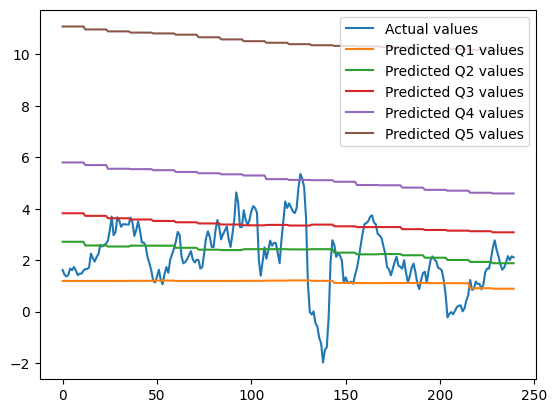

In [8]:
plot_predictions(
    y_pred=naive_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

In [6]:
benchmarks.columns = benchmarks.columns.str.replace(
    r'VG|IAR|UAR',
    'LIT',
    regex=True
)
lit_preds = benchmarks.loc[X_test.index, 'LIT_Q5': 'LIT_Q95']
evaluate_predictions(
    y_pred=lit_preds.values,
    y_true=y_test.values,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)


R1 for q0.05: -57.156998581522615
R1 for q0.25: -20.596640268359057
R1 for q0.5: -18.507116133913183
R1 for q0.75: -13.56743130846716
R1 for q0.95: -26.105981962268075
Mean R1: -27.18683365090602
R2 score: 8.813611252472842


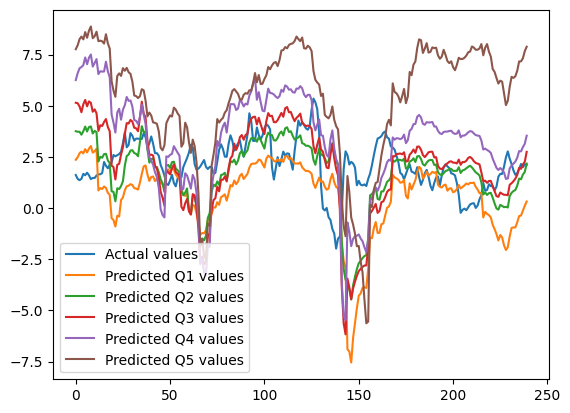

In [10]:
plot_predictions(
    y_pred=lit_preds.values,
    y_true=y_test.values,
    multi_quantile=True
)

## Check training loss at init for a network that predicts the median

In [21]:
quantile = 0.5
subsample_size = X_train_full.shape[0]
learning_rate = 1e-5

for quantile in [0.05, 0.25, 0.5, 0.75, 0.95]:
    model_1 = keras.Sequential(
        [
            keras.layers.Dense(
                32,
                kernel_initializer='zeros',
                bias_initializer='zeros'
            ),
            keras.layers.Dense(
                1, 
                bias_initializer=keras.initializers.Constant(float(y_train_full.quantile(quantile)))
            )
        ]
    )
    model_1.compile(
        optimizer=keras.optimizers.Adam(learning_rate=learning_rate), 
        loss=make_tilted_loss(quantile)
    )

    history = model_1.fit(
        x=X_train_full.values[:subsample_size],
        y=y_train_full.values[:subsample_size],
        epochs=1, 
        batch_size=4,
        validation_data=(X_val, y_val),
        # callbacks=[
        #     keras.callbacks.EarlyStopping(
        #         monitor='val_loss',
        #         min_delta=1e-4,
        #         patience=20,
        #         restore_best_weights=False
        #     )
        # ]
    )

    # Training loss at init should be 
    y_train_full_tf = tf.constant(y_train_full.values, dtype='float32')
    y_mean_tf = tf.constant(y_train_full.quantile(quantile), dtype='float32')
    expected_loss = tilted_loss(y_train_full_tf, y_mean_tf, q=quantile)

    print(
        (f'Initial loss: {np.round(history.history['loss'][0],4)}. '
        f'Expected: {np.round(expected_loss, 4)}')
    )

# plt.plot(history.history['loss'], label='Training loss')
# plt.plot(history.history['val_loss'], label='Validation loss')
# plt.legend()
# plt.show()

105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.1792 - val_loss: 0.0666
Initial loss: 0.1792. Expected: 0.18019999563694
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.6802 - val_loss: 0.1362
Initial loss: 0.6802. Expected: 0.6862999796867371
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0388 - val_loss: 0.6321
Initial loss: 1.0388. Expected: 1.0496000051498413
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 1.0210 - val_loss: 0.7764
Initial loss: 1.021. Expected: 1.0336999893188477
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 2ms/step - loss: 0.3686 - val_loss: 0.4201
Initial loss: 0.3686. Expected: 0.37049999833106995


Loss works, we can move on. Note that to check the initial loss the kernel must be initialized as zero.

# Elastic Net

Epoch 1/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 62.2267 - val_loss: 32.8417
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 58.1915 - val_loss: 30.3701
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 54.3872 - val_loss: 28.0449
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 50.9036 - val_loss: 25.8200
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 47.6831 - val_loss: 23.7939
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 44.7179 - val_loss: 22.0131
Epoch 7/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 42.0208 - val_loss: 20.3483
Epoch 8/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 39.5747 - val_loss: 18.7101
Epoch 9/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 37.3594 - val_loss: 17.1018
Epoch 10/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 35.3072 - val_loss: 15.4850
Epoch 11/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 1ms/step - loss: 33.3689 - val_loss: 14.0697
Epoch 12/200
105/10

<Axes: >

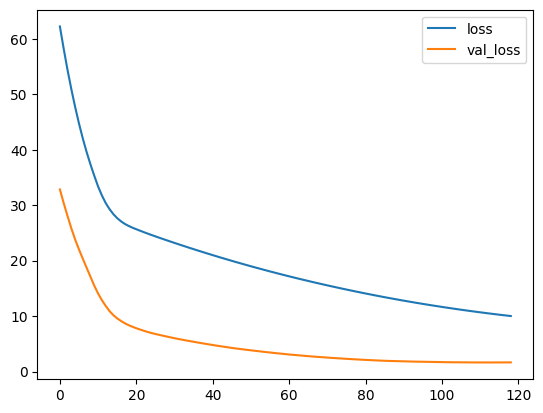

In [ ]:
keras.utils.set_random_seed(1)

builder_params = {
    'lr': 3e-4,
    'l2': 1e-1,
    'l1': 2.0,
    'loss': 'mse',
    'q': 0.5
}

model = build_linear_model(
    **builder_params
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-3,
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_full,
    y_train_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


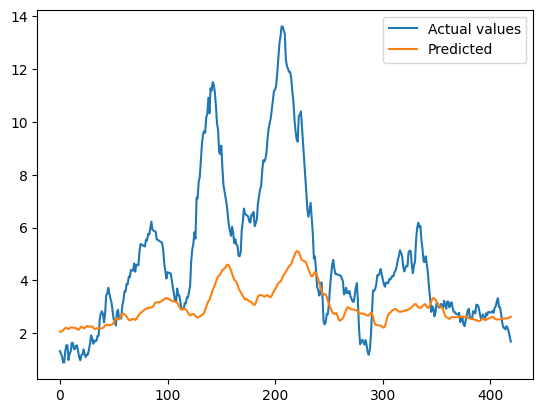

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step 


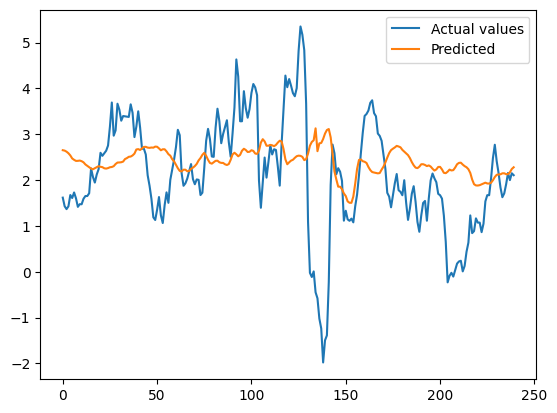

R2 score: 70.15665681729197


In [43]:
y_pred = model.predict(X_train_full)
plot_predictions(
    y_pred=y_pred,
    y_true=y_train_full.values
)

y_pred = model.predict(X_test)
plot_predictions(
    y_pred=y_pred,
    y_true=y_test.values
)

evaluate_predictions(
    y_pred=y_pred,
    y_true=y_test.values,
    mean_benchmark=naive_mean,
    eval_quantiles=False
)

Best MSE config: 
    - lr around 3e-4
    - l1 <= 2.0

# NN

Epoch 1/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 2s 3ms/step - loss: 357.3730 - val_loss: 306.8930
Epoch 2/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 295.8243 - val_loss: 252.6348
Epoch 3/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 244.2338 - val_loss: 207.5393
Epoch 4/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 200.8573 - val_loss: 170.2813
Epoch 5/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 164.4448 - val_loss: 140.0951
Epoch 6/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 134.5570 - val_loss: 115.5499
Epoch 7/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 110.5010 - val_loss: 95.4882
Epoch 8/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 91.0743 - val_loss: 78.7509
Epoch 9/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 75.2610 - val_loss: 65.0527
Epoch 10/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 62.8164 - val_loss: 54.3446
Epoch 11/200
105/105 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 53.1729 - val_loss: 45.8902
Epoch 

<Axes: >

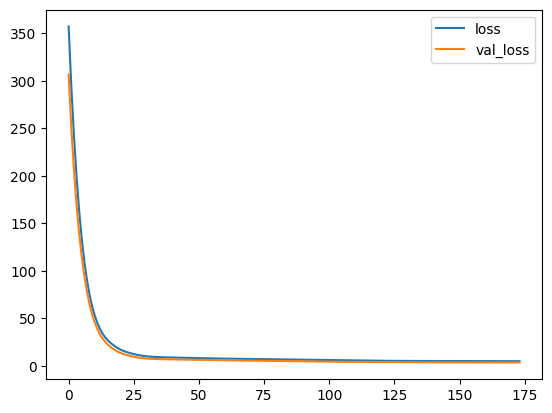

In [53]:
keras.utils.set_random_seed(1)

builder_params = {
    'n_layers': 2,
    'n_nodes': 16,
    'lr': 3e-4,
    'l2': 1.0,
    'l1': 1.0,
    'loss': 'mse',
    'q': 0.5
}

model = build_nn(
    **builder_params
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-3,
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_full,
    y_train_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val, y_val),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

14/14 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step


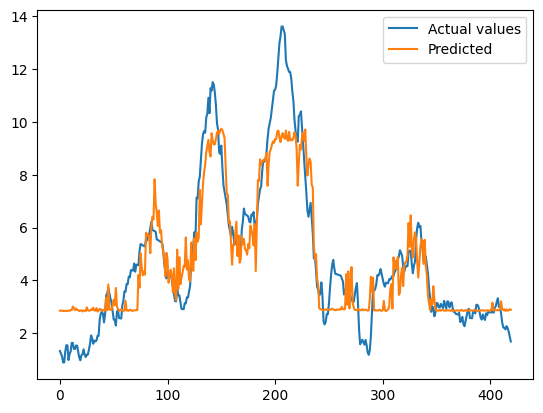

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step 


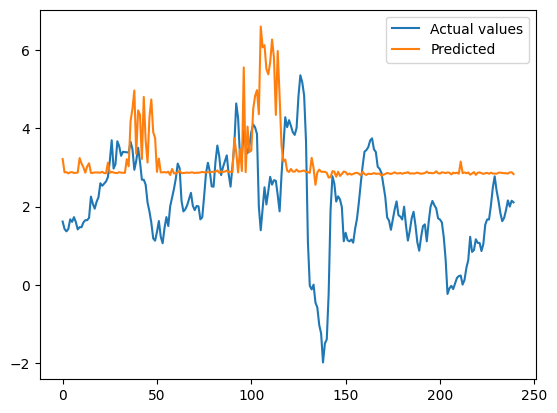

R2 score: 50.11268533654679


In [54]:
y_pred = model.predict(X_train_full)
plot_predictions(
    y_pred=y_pred,
    y_true=y_train_full.values
)

y_pred = model.predict(X_test)
plot_predictions(
    y_pred=y_pred,
    y_true=y_test.values
)

evaluate_predictions(
    y_pred=y_pred,
    y_true=y_test.values,
    mean_benchmark=naive_mean,
    eval_quantiles=False
)

## Notes

- 1 layer is best (32 nodes)
- l2,l1 <= 1.0

# RNN data

In [22]:
import json

with open('data/fred_group_dict.json', 'r') as f:
    fred_group_dict = json.load(f)

fred_groups = list(fred_group_dict.values())

In [7]:
rnn_data = prepare_rnn_data(
    targets_path=TARGETS_PATH,
    input_paths=INPUT_PATHS,
    start_date=START_DATE,
    train_cutoff_year=YEAR,
    val_months=VAL_MONTHS,
    test_months=TEST_MONTHS,
    n_timesteps=12,
    split_groups=None
)

(
    X_train_rnn,
    X_val_rnn,
    X_test_rnn,
    targets_train_rnn,
    targets_val_rnn,
    targets_test_rnn
) = rnn_data

if not isinstance(X_train_rnn, list):
    print(X_train_rnn.shape, X_val_rnn.shape, X_test_rnn.shape)

    X_train_rnn = np.delete(X_train_rnn, indicies_to_drop, axis=2)
    X_val_rnn = np.delete(X_val_rnn, indicies_to_drop, axis=2)
    X_test_rnn = np.delete(X_test_rnn, indicies_to_drop, axis=2)
else:
    print([X.shape for X in X_train_rnn])
    print([X.shape for X in X_val_rnn])
    print([X.shape for X in X_test_rnn])

print(targets_train_rnn.shape, targets_val_rnn.shape, targets_test_rnn.shape)



# Create single target vector
y_train_rnn = targets_train_rnn[:,TARGET_IDX]
y_val_rnn = targets_val_rnn[:,TARGET_IDX]
y_test_rnn = targets_test_rnn[:, TARGET_IDX]

# mq_y_train_rnn = np.repeat(y_train_rnn.reshape(-1,1), len(QUANTILES), axis=1)
# mq_y_val_rnn = np.repeat(y_val_rnn.reshape(-1,1), len(QUANTILES), axis=1)
# mq_y_test_rnn = np.repeat(y_test_rnn.reshape(-1,1), len(QUANTILES), axis=1)

# Stack up the sequences to create a full training set
if isinstance(X_train, list):
    X_train_rnn_full = concatenate_multi_input_data(X_train_rnn, X_val_rnn)
else:
    X_train_rnn_full = np.concatenate([X_train_rnn, X_val_rnn])
# mq_y_train_rnn_full = np.concatenate([mq_y_train_rnn, mq_y_val_rnn], axis=0)
y_train_rnn_full = np.concatenate([y_train_rnn, y_val_rnn], axis=0)

(349, 12, 135) (60, 12, 135) (240, 12, 135)
(349, 3) (60, 3) (240, 3)


In [ ]:
X_train_rnn_full.shape

(409, 12, 161)

# RNN

Epoch 1/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 4s 10ms/step - loss: 1743.2080 - val_loss: 1413.2821
Epoch 2/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 1167.6364 - val_loss: 919.3875
Epoch 3/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 734.5653 - val_loss: 557.7699
Epoch 4/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 432.1370 - val_loss: 317.2246
Epoch 5/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 245.0682 - val_loss: 184.1022
Epoch 6/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 155.6348 - val_loss: 130.4551
Epoch 7/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 116.7872 - val_loss: 100.9228
Epoch 8/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 92.6283 - val_loss: 80.6640
Epoch 9/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 75.2275 - val_loss: 65.4083
Epoch 10/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 61.8808 - val_loss: 53.4855
Epoch 11/200
103/103 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - loss: 51.1973 - val_loss: 43.7606
E

<Axes: >

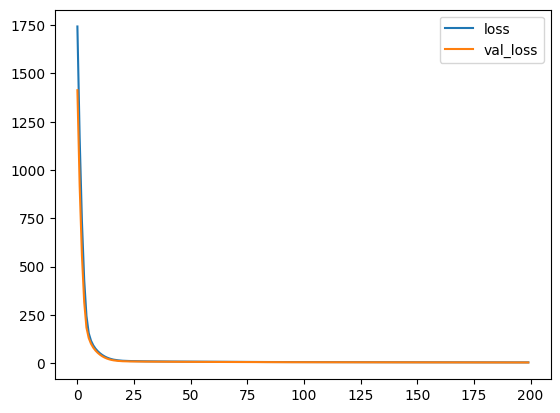

In [ ]:
keras.utils.set_random_seed(1)

builder_params = {
    'n_recurrent_layers': 1,
    'n_dense_layers': 1,
    'n_nodes': 32,
    'lr': 3e-4,
    'l2': 1.0,
    'l1': 0.2,
    'rec_drop': 0.2,
    'loss': 'mse',
    'q': 0.5
}

model = build_rnn(
    **builder_params
)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-3,
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_rnn_full,
    y_train_rnn_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

13/13 ━━━━━━━━━━━━━━━━━━━━ 1s 25ms/step


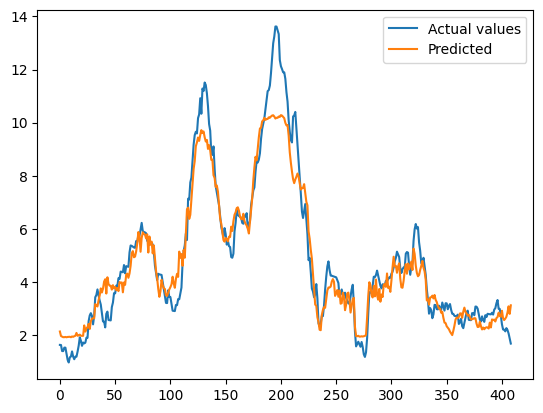

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step 


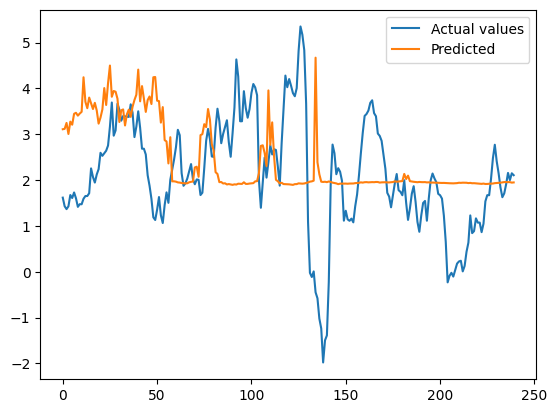

R2 score: 63.30760956987049


In [17]:
y_pred = model.predict(X_train_rnn_full)
plot_predictions(
    y_pred=y_pred,
    y_true=y_train_rnn_full
)

y_pred = model.predict(X_test_rnn)
plot_predictions(
    y_pred=y_pred,
    y_true=y_test_rnn
)

evaluate_predictions(
    y_pred=y_pred,
    y_true=y_test_rnn,
    mean_benchmark=naive_mean,
    eval_quantiles=False
)

# New DMQ

Epoch 1/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 9s 24ms/step - loss: 14.4342 - val_loss: 12.5468
Epoch 2/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 12.8453 - val_loss: 11.5987
Epoch 3/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 10ms/step - loss: 11.7850 - val_loss: 10.8856
Epoch 4/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 10.9582 - val_loss: 10.1633
Epoch 5/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 10.1901 - val_loss: 9.4448
Epoch 6/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 9.4602 - val_loss: 8.7570
Epoch 7/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 8.7699 - val_loss: 8.0960
Epoch 8/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step - loss: 8.1205 - val_loss: 7.4721
Epoch 9/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 7.5103 - val_loss: 6.8800
Epoch 10/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.9401 - val_loss: 6.3370
Epoch 11/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 6.4090 - val_loss: 5.8267
Epoch 12/200
60/60 ━━━━━━━━━━━━━━━━━━━━ 1s 8ms/step

<Axes: >

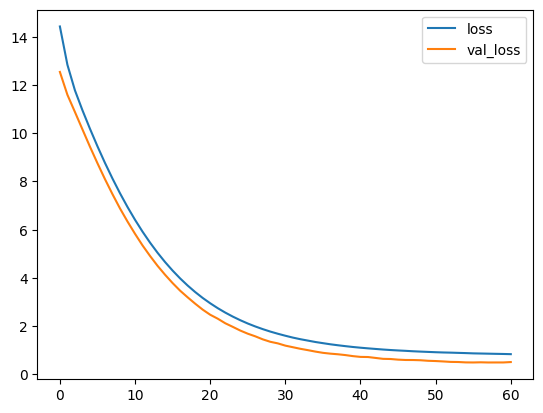

In [ ]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

bias_initializers = {
    q: keras.initializers.Constant(y_train.iloc[-12:].quantile(q)) for q in QUANTILES
}

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 2, 
    'n_shared_layers': 2, 
    'n_qtask_layers': 2, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'he_normal',
    'quantiles': QUANTILES, 
    'loss_weights':  None,
    'bias_initializers':  None,
    'space_quantiles': False,
    'loss': 'quantile'
}

hps = {
    'lr': 3e-4,
    'l2': 0.01
}

builder_params.update(hps)

model = build_dmq(
    **builder_params
)

# keras.utils.plot_model(model)

early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-3,
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_rnn_full[-120:],
    y_train_rnn_full[-120:],
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

In [32]:
0.2/60

0.0033333333333333335

11/11 ━━━━━━━━━━━━━━━━━━━━ 1s 52ms/step


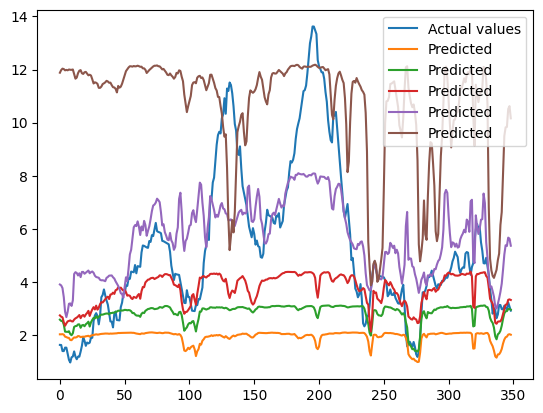

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


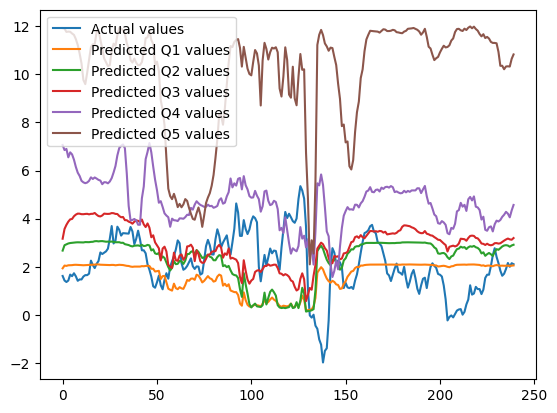

R1 for q0.05: -99.94120808651658
R1 for q0.25: -39.827163570107786
R1 for q0.5: -2.66212524454692
R1 for q0.75: 7.021113571286108
R1 for q0.95: 6.8115896373437295
Mean R1: -25.719558738508294
R2 score: -12.701810890077937


In [ ]:
y_pred = model.predict(X_train_rnn)
plot_predictions(
    y_pred=y_pred, 
    y_true=y_train_rnn.flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_predictions(
    y_pred=y_pred,
    y_true=y_test_rnn.flatten(),
    multi_quantile=True
    )

evaluate_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

# DMQ

Epoch 1/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 11s 15ms/step - loss: 0.9908 - val_loss: 0.1920
Epoch 2/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.3036 - val_loss: 0.0977
Epoch 3/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1965 - val_loss: 0.1066
Epoch 4/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1588 - val_loss: 0.0910
Epoch 5/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1411 - val_loss: 0.0717
Epoch 6/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1197 - val_loss: 0.0961
Epoch 7/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1137 - val_loss: 0.0658
Epoch 8/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1007 - val_loss: 0.0882
Epoch 9/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.0986 - val_loss: 0.0517
Epoch 10/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1027 - val_loss: 0.0464
Epoch 11/200
109/109 ━━━━━━━━━━━━━━━━━━━━ 1s 9ms/step - loss: 0.1070 - val_loss: 0.0696
Epoch 12/200
109/109 ━━━━━━━━━━━━━━━━━━

<Axes: >

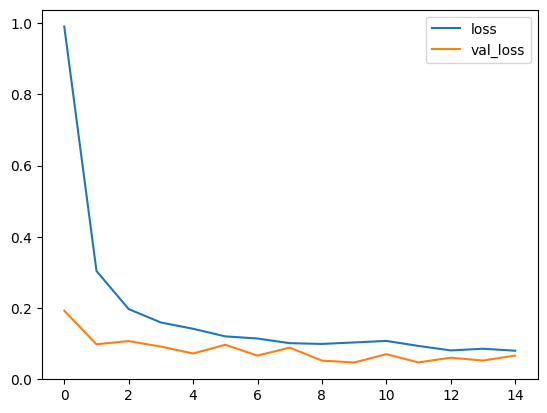

In [ ]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 2, 
    'n_shared_layers': 2, 
    'n_qtask_layers': 2, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'he_normal',
    'lower_quantiles': None, 
    'upper_quantiles': None, 
    'loss_weights':  [1.0]*len(QUANTILES),
    'bias_initializers':  None
}

hps = {
    'l1': 0.0,
    'l2': 0.0,
    'lr': 1e-3
}

builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5
)

history = model.fit(
    X_train_rnn_full,
    y_train_rnn_full,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step 


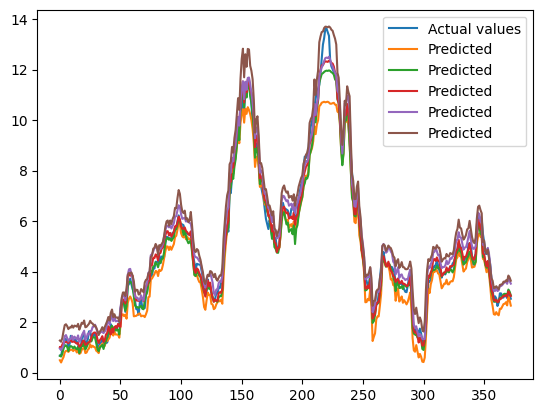

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step 


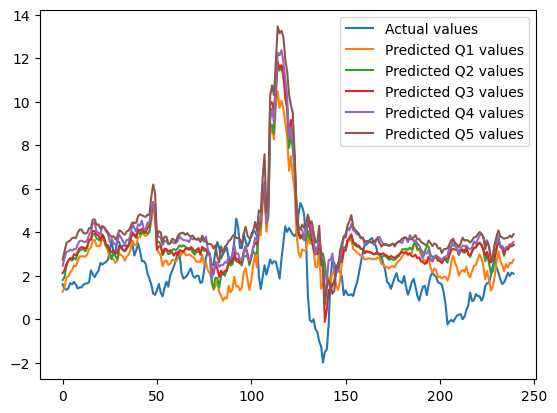

R1 for q0.05: -504.0604702086279
R1 for q0.25: -136.27420274163345
R1 for q0.5: -19.48333888018807
R1 for q0.75: 30.856112146030334
R1 for q0.95: 65.3869646597902
Mean R1: -112.71498700492577
R2 score: -6.13399065441409


In [ ]:
y_pred = model.predict(X_train_rnn)
plot_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)

## Add l2 penalty

In [14]:
input_shapes

[(12, 123)]

Epoch 1/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 12s 20ms/step - loss: 2.7878 - val_loss: 2.4171
Epoch 2/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 2.2625 - val_loss: 2.0102
Epoch 3/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.8364 - val_loss: 1.6488
Epoch 4/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.4897 - val_loss: 1.3502
Epoch 5/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 1.2114 - val_loss: 1.1087
Epoch 6/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.9895 - val_loss: 0.9134
Epoch 7/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.8115 - val_loss: 0.7566
Epoch 8/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.6739 - val_loss: 0.6419
Epoch 9/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.5646 - val_loss: 0.5426
Epoch 10/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4782 - val_loss: 0.4731
Epoch 11/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/step - loss: 0.4096 - val_loss: 0.4081
Epoch 12/200
94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 11ms/ste

<Axes: >

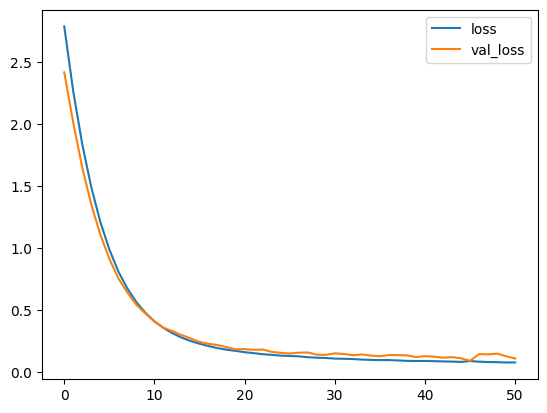

In [42]:
keras.utils.set_random_seed(1)

input_shapes = [X_train_rnn.shape[1:]] if not isinstance(X_train_rnn, list) else [X.shape[1:] for X in X_train_rnn]

bias_initializers = {
    q: keras.initializers.Constant(y_train.iloc[-12:].quantile(q)) for q in QUANTILES
}

builder_params = {
    'input_shapes': input_shapes, 
    'n_recurrent_layers': 2, 
    'n_shared_layers': 2, 
    'n_qtask_layers': 2, 
    'n_recurrent_nodes': 32,
    'n_shared_nodes':32,
    'n_task_nodes': 32,
    'initializer': 'glorot_uniform',
    'lower_quantiles': [.05, .25], 
    'upper_quantiles': [.75, .95], 
    'loss_weights':  [.28, .17, .11, .17, .28],
    'bias_initializers':  bias_initializers
}

hps = {
    'l1': 0.0,
    'l2': 5e-3,
    'rec_drop': 0.0,
    'lr': 3e-4
}

builder_params.update(hps)

model = build_dmq_v0(
    **builder_params
)


early_stopping = EarlyStopping(
    monitor='val_loss',
    min_delta=1e-4,
    patience=5,
    restore_best_weights=True
)

history = model.fit(
    X_train_rnn,
    mq_y_train_rnn,
    epochs=200,
    batch_size=4,
    validation_data=(X_val_rnn, mq_y_val_rnn),
    callbacks=[
        early_stopping
    ],
    verbose=1,
    shuffle=True
)

pd.DataFrame(history.history).plot()

12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 58ms/step


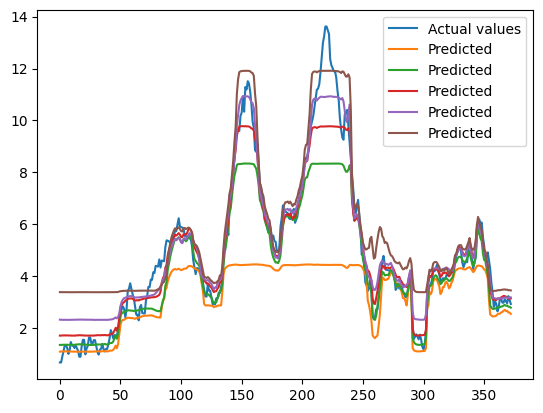

2/2 ━━━━━━━━━━━━━━━━━━━━ 0s 29ms/step


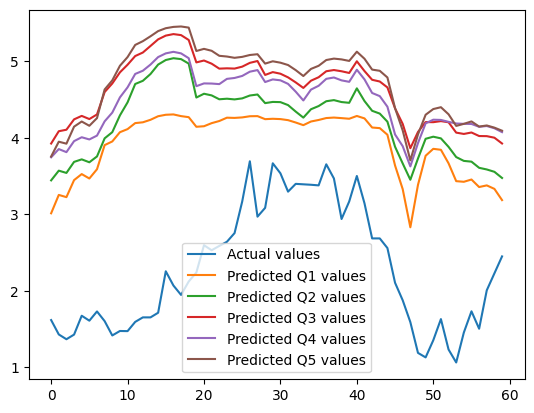

R1 for q0.05: -2602.199261643561
R1 for q0.25: -209.98267797777456
R1 for q0.5: -70.34033843851073
R1 for q0.75: 33.84976608541663
R1 for q0.95: 71.65249568891832
Mean R1: -555.4040032571022
R2 score: 6.818506651480128


In [ ]:
y_pred = model.predict(X_train_rnn)
plot_predictions(
    y_pred=y_pred, 
    y_true=mq_y_train_rnn[:,0].flatten()
    )

y_pred = model.predict(X_test_rnn)
mean_pred = y_pred @ np.array([0.15, 0.225, 0.25, 0.225, 0.15]).reshape(-1,1)
plot_predictions(
    y_pred=y_pred,
    y_true=mq_y_test_rnn[:,0].flatten(),
    multi_quantile=True
    )

evaluate_predictions(
    y_pred, 
    y_test_rnn,
    q_benchmarks=naive_preds.values,
    mean_benchmark=naive_mean.values
)